# *E. coli* Fatty Acid Synthesis — Deterministic ODE Model

Simulates the type II FAS pathway using mass-action kinetics. Reaction networks are defined in YAML files and loaded at runtime; the resulting ODE system is solved with JAX + diffrax.

**Workflow:** build network → reaction sanity check → set initial conditions → solve ODEs → make plots

---
*Annette Thompson · Fox and Shirts Labs, CU Boulder · 2026 · Developed with assistance from GitHub Copilot (Claude Sonnet 4.6)*

## Step 1: Load Reaction Network

**What to update before running:**
- **`REACTIONS_PATH`** — set this to the folder containing your YAML reaction files. Update to `Path('../Reactions/EC_FAS_ME1')` once the full YAML folder is in place.

`build_ode_system_from_reactions()` returns:
- `network` — equinox module implementing the ODE right-hand side
- `species` — ordered list of species names
- `params` — ordered list of parameter names
- `param_values` — dict of default rate constants loaded from the YAML files
- `scaling_groups` — named groups of rate constants that can be rescaled together

The `sp`, `pm`, `rn`, and `sg` namespace objects enable **tab-completion**: type `sp.` and press Tab to browse all species, `pm.` for parameters, etc.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "../")

from pathlib import Path
import re
import os
import json

import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import diffrax as dfrx
import pandas as pd
import itertools
from scipy.optimize import minimize

from Utilities.reaction_model_builder import (
    build_ode_system_from_reactions,
    load_elementary_reactions,
    make_namespace,
    make_reaction_namespace,
    set_scaling_group_values
)

REACTIONS_PATH = Path('../Reactions/EC_FAS_ME1')

network, species, params, param_values, scaling_groups = build_ode_system_from_reactions(REACTIONS_PATH)
rxns = load_elementary_reactions(REACTIONS_PATH)

# Namespaces enable tab-completion: sp.ACP, pm.k3_1f, rn.FabG_binding_NADPH
sp = make_namespace(species)
pm = make_namespace(params)
rn = make_reaction_namespace(rxns)
sg = make_namespace(scaling_groups)

theta = jnp.array([param_values[p] for p in params], dtype=jnp.float64)

print(f'Loaded {len(species)} species, {len(params)} params, {len(rxns)} reactions, and {len(scaling_groups)} scaling groups.')

Loaded 320 species, 222 params, 334 reactions, and 18 scaling groups.


## Step 2: Sanity Checks

Checks reaction definitions for common errors before committing to a long simulation:
- Mass balance (atoms conserved across each reaction)
- Species continuity (every produced species is also consumed somewhere)
- Chain-set consistency (for fatty acid chain-length templates)
- Suspiciously similar rate-constant names (typo detection)
- Zero-valued rate constants

In [2]:
import importlib, Utilities.reaction_sanity_check
importlib.reload(Utilities.reaction_sanity_check)
from Utilities.reaction_sanity_check import run_all_checks

sanity = run_all_checks(rxns)

Running sanity checks on 334 expanded reactions

══════════════════════════════════════════════════════════════
MASS BALANCE
  Moieties: Carbon, CoA, ACP, NAD, NADP
  334/334 reactions balanced
  All reactions balanced ✓

══════════════════════════════════════════════════════════════
SPECIES CONTINUITY CHECK
  Total species:                      320
  Never created as a forward product: 5
  Never consumed as a reactant:       54
  Appear in exactly one reaction:     53

  [INFO] Never created in forward reactions (starting substrates check):


species,used_in
C2_AcACP,"FabB_binding_C2_AcACP, FabF_binding_C2_AcACP"
C2_AcCoA,"C2_FabB_binding_AcCoA, C2_FabF_binding_AcCoA, C2_FabH_binding_AcCoA"
C3_MalCoA,FabD_binding_MalCoA
NADH,FabI_binding_NADH
NADPH,FabG_binding_NADPH



  [INFO] Never consumed in forward reactions (terminal products or sinks check):


species,produced_in
C10_FA,C10_TesA_hydrolysis_release_FA
C10_FabH_AcACP,C10_FabH_inhibition_by_AcACP
C10_FabH_Act_AcACP,C8_C2_FabH_Act_inhibition_by_AcACP
C12_FA,C12_TesA_hydrolysis_release_FA
C12_FA_unsat,C12_TesA_hydrolysis_release_FA_unsat
C12_FabH_AcACP,C12_FabH_inhibition_by_AcACP
C12_FabH_AcACP_unsat,C12_FabH_inhibition_by_AcACP_unsat
C12_FabH_Act_AcACP,C10_C2_FabH_Act_inhibition_by_AcACP
C14_FA,C14_TesA_hydrolysis_release_FA
C14_FA_unsat,C14_TesA_hydrolysis_release_FA_unsat



  [WARN] Species appearing in exactly one reaction (possible dead-end or mistype):


...


══════════════════════════════════════════════════════════════
ZERO-RATE REACTIONS
  6 reaction(s) with at least one zero rate constant:


rxn_name,direction,expression
C4_FabB_Act_condensation_release_BKeAcACP,forward,C5_FabB_Act_MalACP --> FabB + C4_BKeAcACP + C1_CO2
C2_FabF_binding_AcCoA,both,FabF + C2_AcCoA <--> C2_FabF_AcCoA
C2_FabF_AcCoA_activation,both,C2_FabF_AcCoA <--> C2_FabF_Act + CoA
C4_FabF_Act_condensation_release_BKeAcACP,forward,C5_FabF_Act_MalACP --> FabF + C4_BKeAcACP + C1_CO2
C10_cis_FabZ_dehydration,both,C10_FabZ_EnAcACP <--> C10_FabZ_cis3EnAcACP
C10_cis_FabZ_release_EnAcACP,both,C10_FabZ_cis3EnAcACP <--> FabZ + C10_cis3EnAcACP



══════════════════════════════════════════════════════════════
IRREVERSIBLE ACCUMULATION AND DRAIN CHECK
  Irreversibly generated, never consumed: 17
  Irreversibly consumed, never generated: 0

  [ACCUMULATE] Generated by irreversible reaction(s) but never consumed:


species,source_reactions
C10_FA,C10_TesA_hydrolysis_release_FA
C12_FA,C12_TesA_hydrolysis_release_FA
C12_FA_unsat,C12_TesA_hydrolysis_release_FA_unsat
C14_FA,C14_TesA_hydrolysis_release_FA
C14_FA_unsat,C14_TesA_hydrolysis_release_FA_unsat
C16_FA,C16_TesA_hydrolysis_release_FA
C16_FA_unsat,C16_TesA_hydrolysis_release_FA_unsat
C18_FA,C18_TesA_hydrolysis_release_FA
C18_FA_unsat,C18_TesA_hydrolysis_release_FA_unsat
C1_CO2,"C6_FabB_condensation_release_BKeAcACP, C8_FabB_condensation_release_BKeAcACP, C10_FabB_condensation_release_BKeAcACP, C12_FabB_condensation_release_BKeAcACP, C14_FabB_condensation_release_BKeAcACP, C16_FabB_condensation_release_BKeAcACP, C18_FabB_condensation_release_BKeAcACP, C20_FabB_condensation_release_BKeAcACP, C14_FabB_condensation_release_BKeAcACP_unsat, C16_FabB_condensation_release_BKeAcACP_unsat, C18_FabB_condensation_release_BKeAcACP_unsat, C20_FabB_condensation_release_BKeAcACP_unsat, C12_FabB_condensation_release_BKeAcACP_unsat, FabB_decarboxylating_MalACP, C4_FabB_Act_condensation_release_BKeAcACP, C6_FabF_condensation_release_BKeAcACP, C8_FabF_condensation_release_BKeAcACP, C10_FabF_condensation_release_BKeAcACP, C12_FabF_condensation_release_BKeAcACP, C14_FabF_condensation_release_BKeAcACP, C16_FabF_condensation_release_BKeAcACP, C18_FabF_condensation_release_BKeAcACP, C20_FabF_condensation_release_BKeAcACP, C14_FabF_condensation_release_BKeAcACP_unsat, C16_FabF_condensation_release_BKeAcACP_unsat, C18_FabF_condensation_release_BKeAcACP_unsat, C20_FabF_condensation_release_BKeAcACP_unsat, FabF_decarboxylating_MalACP, C4_FabF_Act_condensation_release_BKeAcACP, C5_FabH_Act_condensation_release_BKeAcACP"



══════════════════════════════════════════════════════════════
PARAMETER CONFLICT CHECK
  No parameter conflicts ✓


## Tools for Inspecting Reactions

Use these helpers to debug reaction definitions and quickly inspect model structure.

`rxns.query(query, query_type, *, return_type="expression")` searches reactions by field.

- `query_type` (required): `"species"`, `"reactant"`, `"product"`, `"parameter"`, `"scaling"`, or any reaction attribute (for example `"rxn_name"`)
- `query`: substring text (contains match) or a namespace index like `sp.X`, `pm.k`, `sg.a1` (exact match); can use Regular Expression to search for patterns (requires use_regex = True)
- `return_type` (optional): `"expression"` (default), `"parameters"` (includes parameter values), `"scaling"`, `"ode_terms"`, or `"scaled_rate_constants"` (effective rate = base × scaling factor; requires `theta=theta`)

`rxns.get_ode_terms(sp.X)` is a shortcut for the species mass-balance view.

In [6]:
rxns.query("FabD", "species", return_type="expression",use_regex=True, theta=theta)

4 match(es) | species='FabD' | return=expression


rxn_name,reaction,rate_expression
FabD_binding_MalCoA,FabD + C3_MalCoA <--> C3_FabD_MalCoA,kon_D_MalCoA * FabD * C3_MalCoA <--> a1 * koff_D_MalCoA * C3_FabD_MalCoA
FabD_activation_release_CoA,C3_FabD_MalCoA <--> C3_FabD_Act + CoA,(b1/b2) * kfwd_D_MalCoA * C3_FabD_MalCoA <--> b1 * krvs_D_MalCoA * C3_FabD_Act * CoA
FabD_Act_binding_ACP,C3_FabD_Act + ACP <--> C3_FabD_Act_ACP,kon_D_Act_ACP * C3_FabD_Act * ACP <--> a1 * koff_D_Act_ACP * C3_FabD_Act_ACP
FabD_catalysis_release_MalACP,C3_FabD_Act_ACP <--> FabD + C3_MalACP,(b1/b3) * kfwd_D_Act_ACP * C3_FabD_Act_ACP <--> b1 * krvs_D_Act_ACP * FabD * C3_MalACP


## Step 3: Simulation Parameters

**What to change here:**
- **`y0[sp.X] = value`** — starting concentration (µM) of each species (substrates).
- **`enzyme_concs`** — enzyme starting concentrations (µM).
- **`SCALING_GROUPS`** — scalar multipliers applied uniformly to all rate constants in a named group (groups set in reaction files).

In [4]:
y0 = np.zeros(len(species), dtype=np.float64)

# Substrates (µM) - set non-zero starting concentrations 
# (NADPH and NADH are typically set to 1000 uM, 
# other concentrations should align with in vitro experiments)
y0[sp.C2_AcCoA]  = 500.0
y0[sp.C3_MalCoA] = 500.0
y0[sp.ACP]       = 10.0
y0[sp.NADPH]     = 1000.0
y0[sp.NADH]      = 1000.0

# Enzymes (µM)
enzyme_concs = {
    sp.FabD: 1, sp.FabH: 1, sp.FabG: 1, sp.FabZ: 0,
    sp.FabI: 0, sp.TesA: 0, sp.FabF: 0, sp.FabA: 0, sp.FabB: 0,
}
for idx, conc in enzyme_concs.items():
    y0[idx] = float(conc)

# Scaling group values - setting to 1 or 0 will leave parameters alone 
# depending on the scaling parameter (some are within expressions used to scale)
SCALING_GROUPS = {
    "a1": 1, "a2": 1, "a3": 1,
    "b1": 1, "b2": 1, "b3": 1,
    "c1": 1, "c2": 1, "c3": 1, "c4": 1,
    "d1": 0, "d2": 0, "e": 1, "f": 1,
    "x1": 1, "x2": 1, "x3": 1, "x4": 1,
}
theta = set_scaling_group_values(theta, params, SCALING_GROUPS)

## Step 4: Solve ODEs

**What to change here:**
- **`time_range = [0.0, 720.0]`** — simulation start and end time in **seconds** (720 s = 12 min (product profile), 150 s = 2.5 min (initial rate)). Increase the upper bound to let the system approach steady state.

The solver used is **Kvaerno5** — an implicit, stiff-safe 5th-order Runge–Kutta method with adaptive step size via a PID controller. Every accepted step is saved; trailing NaN padding is trimmed after solving. Time units are **seconds** internally.

In [6]:
def run_odes(time_range, y0, theta_run):
    
    sol = dfrx.diffeqsolve(
        dfrx.ODETerm(network),
        dfrx.Kvaerno5(),
        t0=time_range[0], t1=time_range[1], dt0=1e-6,
        y0=jnp.asarray(y0, dtype=jnp.float64),
        args=theta_run,
        saveat=dfrx.SaveAt(steps=True),
        stepsize_controller=dfrx.PIDController(
            rtol=1e-3, atol=1e-6, pcoeff=0.2, icoeff=0.4, dcoeff=0,
        ),
        max_steps=1_000,
        throw=True,
    )

    num_ac_steps = int(np.asarray(sol.stats['num_accepted_steps']))

    T = sol.ts[:num_ac_steps]
    C = sol.ys[:num_ac_steps, :]

    num_tot_steps = int(np.asarray(sol.stats['num_steps']))
    print(f"{num_ac_steps} accepted steps, {num_tot_steps} total steps.")

    return T, C


time_range = [0.0, 150.0]  # seconds

T, C = run_odes(time_range, y0, theta)

64 accepted steps, 72 total steps.


## Results

### Fatty Acid Chain-Length Profile

Stacked bar chart of final (end-of-simulation) fatty acid mole fractions, split by saturated vs. unsaturated. Species matching `C<n>_FA` and `C<n>_FA_un` are collected and totaled across all chain lengths.

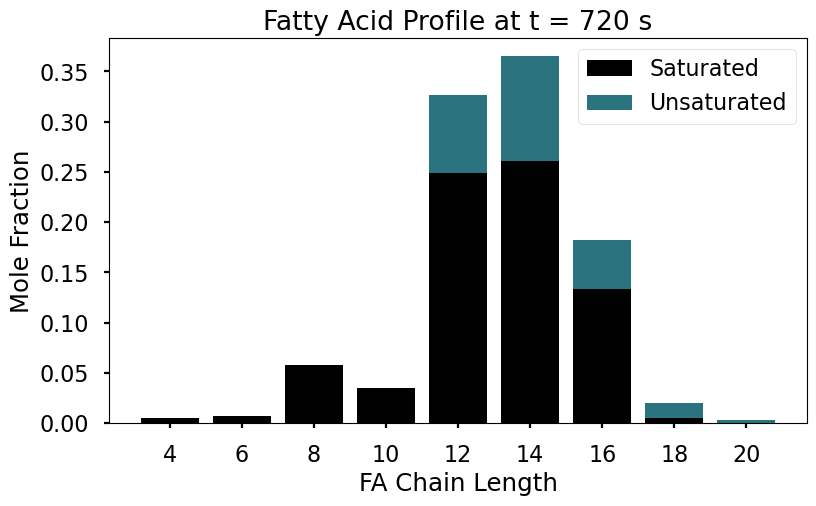

In [6]:
# Collect final concentrations of all C<n>_FA (sat) and C<n>_FA_un (unsat) species
SP_PATTERN = re.compile(r'^C(\d+)_FA(_unsat)?$')
sat_by_chain: dict[int, float] = {}
unsat_by_chain: dict[int, float] = {}
final_conc = C[-1, :]

for sp_name in species:
    m = SP_PATTERN.match(sp_name)
    if m is None:
        continue
    chain = int(m.group(1))
    val = float(final_conc[getattr(sp, sp_name)])
    (unsat_by_chain if m.group(2) else sat_by_chain)[chain] = \
        (unsat_by_chain if m.group(2) else sat_by_chain).get(chain, 0.0) + val

chains = sorted(set(sat_by_chain) | set(unsat_by_chain))
sat   = np.array([sat_by_chain.get(c, 0.0)   for c in chains])
unsat = np.array([unsat_by_chain.get(c, 0.0) for c in chains])
tot = sat.sum() + unsat.sum()

# Normalize to mole fractions (avoid divide-by-zero if all zero)
sat_frac   = np.divide(sat,   tot, out=np.zeros_like(sat),   where=tot > 0)
unsat_frac = np.divide(unsat, tot, out=np.zeros_like(unsat), where=tot > 0)

plt.style.use('seaborn-v0_8-poster')
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=[plt.cm.gist_earth(i / 4) for i in range(4)]
)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(chains))
ax.bar(x, sat_frac,   label='Saturated')
ax.bar(x, unsat_frac, bottom=sat_frac, label='Unsaturated')
ax.set_xticks(x)
ax.set_xticklabels([str(c) for c in chains])
ax.set_xlabel('FA Chain Length')
ax.set_ylabel('Mole Fraction')
ax.set_title('Fatty Acid Profile at t = {:.0f} s'.format(float(T[-1])))
ax.legend()
plt.show()


### Concentration Trajectories

`plot_species(names)` accepts any mix of `sp.<name>` integer indices or plain string names. Pass `log_y=True` for species that span several orders of magnitude.

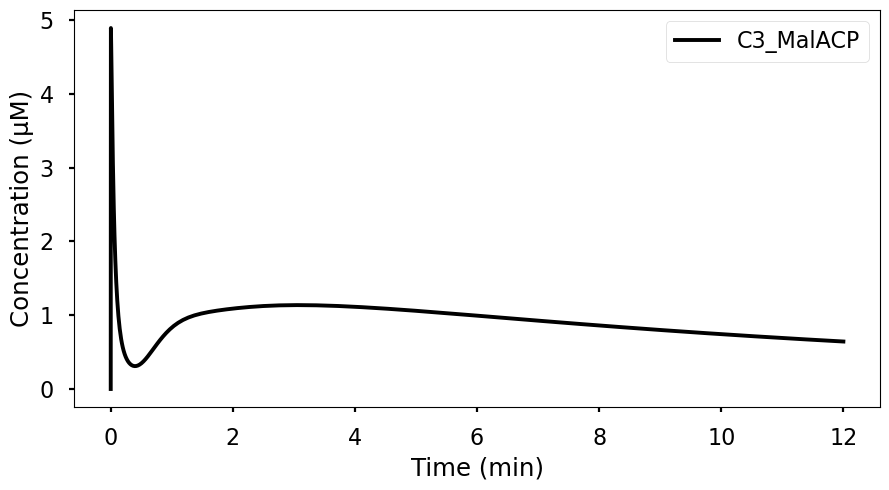

In [7]:
def plot_species(names: list, *, log_y: bool = False) -> None:
    """Plot concentration vs time. Accepts sp.<name> indices or string names."""
    fig, ax = plt.subplots(figsize=(9, 5))
    for name in names:
        idx, label = (name, species[name]) if isinstance(name, int) else (getattr(sp, name), name)
        ax.plot(T / 60, C[:, idx], label=label)
    ax.set_xlabel('Time (min)')
    ax.set_ylabel('Concentration (µM)')
    if log_y:
        ax.set_yscale('log')
    ax.legend()
    fig.tight_layout()
    plt.show()

# CoA-linked substrates
plot_species([sp.C3_MalACP])


### Export to experiment csvs

Quick write up to make data files for running Bayesian inference

In [8]:
# Functions to make timeseries and endpoint CSVs

def choose_species_indices(selected_species=(), species_pattern=None):
    if species_pattern:
        pattern = re.compile(species_pattern)
        selected_names = [sp_name for sp_name in species if pattern.fullmatch(sp_name)]
    else:
        selected_names = list(selected_species)

    missing_species = [sp_name for sp_name in selected_names if sp_name not in species]
    if missing_species:
        raise ValueError(f"Requested species not found in reaction network: {missing_species}")

    if not selected_names:
        raise ValueError("No species selected for export.")

    return [getattr(sp, sp_name) for sp_name in selected_names]


def export_species_time_course(time_range, y0_run, theta_run, target_species_indices, folder_name, save_csv=True):

    T, C = run_odes(time_range, y0_run, theta_run)

    target_species_indices = [int(idx) for idx in target_species_indices]
    species_data = C[:, target_species_indices]
    idx_to_name = {v: k for k, v in vars(sp).items()}
    target_names = [idx_to_name.get(target_species_idx, f"Species_{target_species_idx}") for target_species_idx in target_species_indices]
    
    columns = ["Time (s)"] + [f"{target_name} (uM)" for target_name in target_names]
    df = pd.DataFrame(np.column_stack([T, species_data]), columns=columns)
    
    # Shorten number of rows
    keep_rows = []
    last_accepted_time = None
    
    for i in range(len(df)):
        current_time = df.loc[i, "Time (s)"]
        if last_accepted_time is None and current_time >= 1.0:
            keep_rows.append(i)
            last_accepted_time = current_time
        elif current_time - (last_accepted_time if last_accepted_time is not None else 0) >= 10 and current_time >= 1.2*(last_accepted_time if last_accepted_time is not None else 0):
            keep_rows.append(i)
            last_accepted_time = current_time
            
    df_filtered = df.iloc[keep_rows].reset_index(drop=True)
    
    filename = f"../Data/{folder_name}/time_vs_conc.csv"
    if save_csv:
        df_filtered.to_csv(filename, index=False)
        print(f"Saved to {filename}")
    
    print("Run complete!")
    return df_filtered


def sweep_concentrations(time_range, y0_run, theta_run, varying_species, target_species, folder_name, save_csv=True):

    target_species_indices = [int(idx) for idx in target_species]
    idx_to_name = {v: k for k, v in vars(sp).items()}
    target_species_names = [idx_to_name.get(target_species_idx, f"Species_{target_species_idx}") for target_species_idx in target_species_indices]
    
    varying_species_indices = list(varying_species.keys())
    varying_species_values = list(varying_species.values())
    
    columns = [f"{idx_to_name.get(idx, f'Species_{idx}')} (uM)" for idx in varying_species_indices]
    columns += [f"{name} (uM)" for name in target_species_names]   
    
    results = []
    for combo in itertools.product(*varying_species_values):
        y0_run_copy = y0_run.copy()
        
        for idx, current_conc in zip(varying_species_indices, combo):
            y0_run_copy[idx] = float(current_conc)
            
        _, C = run_odes(time_range, y0_run_copy, theta_run)

        final_vals = [float(C[-1, target_species_idx]) for target_species_idx in target_species_indices]
        results.append(list(combo) + final_vals)
        
    df_sweep = pd.DataFrame(results, columns=columns)

    filename = f"../Data/{folder_name}/init_vs_final_conc.csv"
    if save_csv:
        df_sweep.to_csv(filename, index=False)
        print(f"Saved to {filename}")
        
    print("Sweep complete!")
    return df_sweep

In [9]:
# Experiment 1 - Conc v time

enzyme_name = "Full_FAS_Only_FabD"
os.makedirs(f"../Data/{enzyme_name}", exist_ok=True)

# Base y0
y0 = np.zeros(len(species), dtype=np.float64)
y0[sp.C2_AcCoA]  = 0
y0[sp.C3_MalCoA] = 1
y0[sp.ACP]       = 10
y0[sp.NADPH]     = 0
y0[sp.NADH]      = 0

# Enzymes (µM)
enzyme_concs = {
    sp.FabD: 0.01, sp.FabH: 0, sp.FabG: 0, sp.FabZ: 0,
    sp.FabI: 0, sp.TesA: 0, sp.FabF: 0, sp.FabA: 0, sp.FabB: 0,
}
for idx, conc in enzyme_concs.items():
    y0[idx] = float(conc)

SCALING_GROUPS = {
    "a1": 1, "a2": 1, "a3": 1,
    "b1": 1, "b2": 1, "b3": 1,
    "c1": 1, "c2": 1, "c3": 1, "c4": 1,
    "d1": 0, "d2": 0, "e": 1, "f": 1,
    "x1": 1, "x2": 1, "x3": 1, "x4": 1,
}

theta = set_scaling_group_values(theta, params, SCALING_GROUPS)

time_range = [0,720]

# Choose generated outputs to match the calculation module used for inference.
# For Calculation Files/Full_FAS/FabD_rxns_conc.py:
generated_species = ("C3_MalCoA", "C3_MalACP")
generated_species_pattern = None

# For Calculation Files/Full_FAS/FA_conc.py instead:
# generated_species = ()
# generated_species_pattern = r"^C(\d+)_FA(_unsat)?$"

target_species = choose_species_indices(
    selected_species=generated_species,
    species_pattern=generated_species_pattern,
)

df_filtered = export_species_time_course(time_range, y0, theta, target_species, enzyme_name, save_csv=True)

198 accepted steps, 387 total steps.
Saved to ../Data/Full_FAS_Only_FabD/time_vs_conc.csv
Run complete!


In [10]:
# Experiment 2 - initial conc vs final conc

time_range = [0, 150]

my_sweep_config = {
    sp.FabD: [0.001, 0.01],
    sp.C3_MalCoA: [0.1, 1],
    sp.ACP: [10, 100],
}

df_res = sweep_concentrations(time_range, y0, theta, my_sweep_config, target_species, enzyme_name, save_csv=True)

41 accepted steps, 41 total steps.
41 accepted steps, 41 total steps.
43 accepted steps, 43 total steps.
44 accepted steps, 44 total steps.
47 accepted steps, 47 total steps.
47 accepted steps, 47 total steps.
81 accepted steps, 119 total steps.
51 accepted steps, 51 total steps.
Saved to ../Data/Full_FAS_Only_FabD/init_vs_final_conc.csv
Sweep complete!


## Nested Test Systems: FabD / FabD+FabH / FabD+FabH+FabG

Sampler-benchmark test systems, each a genuinely reduced reaction network
(loaded from an explicit list of individual enzyme YAML files, not the full
`EC_FAS_ME1` folder with other enzymes zeroed out). Each cell rebuilds
`network`/`species`/`sp`/`theta` for its own reduced system and tracks only
its system's final-output species (matching the corresponding
`Calculation Files/Test_*/` module), then exports a timeseries + endpoint
sweep to `Data/Test_*/`.

**Note:** these cells overwrite the global `network`/`species`/`sp`/`theta`
built in Step 1. If you run this notebook top-to-bottom, **Step 5 (Model
Error) below will operate on whichever test system ran last**
(FabD+FabH+FabG), not the full `EC_FAS_ME1` network. Re-run the Step 1 cell
(and Step 3, for `y0`) before Step 5 if you want it to run against the full
network instead.

In [ ]:
# Nested Test System 1: FabD alone
# Initial conditions reused from Results/FabD scaling inference/solver_params.json
# (already tuned/verified for this exact single-enzyme reduced network).

enzyme_name = "Test_FabD"
os.makedirs(f"../Data/{enzyme_name}", exist_ok=True)

REACTIONS_PATH_TEST = [Path('../Reactions/EC_FAS_ME1/FabD.yaml')]
network, species, params, param_values, scaling_groups = build_ode_system_from_reactions(REACTIONS_PATH_TEST)
sp = make_namespace(species)
theta = jnp.array([param_values[p] for p in params], dtype=jnp.float64)

y0 = np.zeros(len(species), dtype=np.float64)
y0[sp.FabD] = 0.001
y0[sp.C3_MalCoA] = 0.1
y0[sp.ACP] = 10

# Only scaling groups present in this reduced network: a1,b1,b2,b3
SCALING_GROUPS = {g: 1 for g in scaling_groups}
theta = set_scaling_group_values(theta, params, SCALING_GROUPS)

time_range = [0, 720]

# Matches Calculation Files/Test_FabD/FabD_conc.py (final-output species only)
generated_species = ("C3_MalACP",)
generated_species_pattern = None

target_species = choose_species_indices(
    selected_species=generated_species,
    species_pattern=generated_species_pattern,
)

df_filtered = export_species_time_course(time_range, y0, theta, target_species, enzyme_name, save_csv=True)

In [ ]:
# Nested Test System 1 (FabD): initial conc vs final conc sweep
# Same sweep grid as Experiment 2 above.

time_range = [0, 150]

my_sweep_config = {
    sp.FabD: [0.001, 0.01],
    sp.C3_MalCoA: [0.1, 1],
    sp.ACP: [10, 100],
}

df_res = sweep_concentrations(time_range, y0, theta, my_sweep_config, target_species, enzyme_name, save_csv=True)

In [ ]:
# Nested Test System 2: FabD + FabH
# Initial conditions empirically verified stable (Kvaerno5, rtol=1e-5/atol=1e-8,
# max_steps=100000) across the full 8-combination endpoint sweep below -- 0 failures.

enzyme_name = "Test_FabD_FabH"
os.makedirs(f"../Data/{enzyme_name}", exist_ok=True)

REACTIONS_PATH_TEST = [
    Path('../Reactions/EC_FAS_ME1/FabD.yaml'),
    Path('../Reactions/EC_FAS_ME1/FabH.yaml'),
]
network, species, params, param_values, scaling_groups = build_ode_system_from_reactions(REACTIONS_PATH_TEST)
sp = make_namespace(species)
theta = jnp.array([param_values[p] for p in params], dtype=jnp.float64)

y0 = np.zeros(len(species), dtype=np.float64)
y0[sp.FabD] = 0.001
y0[sp.C3_MalCoA] = 0.1
y0[sp.ACP] = 10
y0[sp.FabH] = 0.001
y0[sp.C2_AcCoA] = 0.1

# Only scaling groups present in this reduced network: a1,b1,b2,b3,c1,e
SCALING_GROUPS = {g: 1 for g in scaling_groups}
theta = set_scaling_group_values(theta, params, SCALING_GROUPS)

time_range = [0, 720]

# Matches Calculation Files/Test_FabD_FabH/FabD_FabH_conc.py (final-output species only)
generated_species = ("C4_BKeAcACP",)
generated_species_pattern = None

target_species = choose_species_indices(
    selected_species=generated_species,
    species_pattern=generated_species_pattern,
)

df_filtered = export_species_time_course(time_range, y0, theta, target_species, enzyme_name, save_csv=True)

In [ ]:
# Nested Test System 2 (FabD+FabH): initial conc vs final conc sweep
# Exactly 8 combinations (matching System 1's row count for comparability),
# using a standard L8(2^4) orthogonal design so FabD, C3_MalCoA, FabH, and
# C2_AcCoA each still take both their low/high value 4 times. ACP stays
# fixed at the tuned value set above (not varied).

time_range = [0, 150]

FabD_vals   = [0.001, 0.001, 0.001, 0.001, 0.01,  0.01,  0.01,  0.01]
MalCoA_vals = [0.1,   0.1,   1,     1,     0.1,   0.1,   1,     1]
FabH_vals   = [0.001, 0.001, 0.01,  0.01,  0.01,  0.01,  0.001, 0.001]
AcCoA_vals  = [0.1,   1,     0.1,   1,     0.1,   1,     0.1,   1]

idx_to_name = {v: k for k, v in vars(sp).items()}
target_name = idx_to_name[target_species[0]]
rows = []
for FabD_v, MalCoA_v, FabH_v, AcCoA_v in zip(FabD_vals, MalCoA_vals, FabH_vals, AcCoA_vals):
    y0_run = y0.copy()
    y0_run[sp.FabD] = FabD_v
    y0_run[sp.C3_MalCoA] = MalCoA_v
    y0_run[sp.FabH] = FabH_v
    y0_run[sp.C2_AcCoA] = AcCoA_v
    _, C = run_odes(time_range, y0_run, theta)
    rows.append([FabD_v, MalCoA_v, FabH_v, AcCoA_v, float(C[-1, target_species[0]])])

df_res = pd.DataFrame(
    rows,
    columns=["FabD (uM)", "C3_MalCoA (uM)", "FabH (uM)", "C2_AcCoA (uM)", f"{target_name} (uM)"],
)
filename = f"../Data/{enzyme_name}/init_vs_final_conc.csv"
df_res.to_csv(filename, index=False)
print(f"Saved to {filename}")

In [ ]:
# Nested Test System 3: FabD + FabH + FabG
# Initial conditions empirically verified stable (Kvaerno5, rtol=1e-5/atol=1e-8,
# max_steps=100000) across the full 8-combination endpoint sweep below -- 0 failures.

enzyme_name = "Test_FabD_FabH_FabG"
os.makedirs(f"../Data/{enzyme_name}", exist_ok=True)

REACTIONS_PATH_TEST = [
    Path('../Reactions/EC_FAS_ME1/FabD.yaml'),
    Path('../Reactions/EC_FAS_ME1/FabH.yaml'),
    Path('../Reactions/EC_FAS_ME1/FabG.yaml'),
]
network, species, params, param_values, scaling_groups = build_ode_system_from_reactions(REACTIONS_PATH_TEST)
sp = make_namespace(species)
theta = jnp.array([param_values[p] for p in params], dtype=jnp.float64)

y0 = np.zeros(len(species), dtype=np.float64)
y0[sp.FabD] = 0.001
y0[sp.C3_MalCoA] = 0.1
y0[sp.ACP] = 10
y0[sp.FabH] = 0.001
y0[sp.C2_AcCoA] = 0.1
y0[sp.FabG] = 0.001
y0[sp.NADPH] = 10

# Only scaling groups present in this reduced network: a1,a2,b1,b2,b3,c1,c2,e
SCALING_GROUPS = {g: 1 for g in scaling_groups}
theta = set_scaling_group_values(theta, params, SCALING_GROUPS)

time_range = [0, 720]

# Matches Calculation Files/Test_FabD_FabH_FabG/FabD_FabH_FabG_conc.py (final-output species only)
generated_species = ("C4_BHyAcACP",)
generated_species_pattern = None

target_species = choose_species_indices(
    selected_species=generated_species,
    species_pattern=generated_species_pattern,
)

df_filtered = export_species_time_course(time_range, y0, theta, target_species, enzyme_name, save_csv=True)

In [ ]:
# Nested Test System 3 (FabD+FabH+FabG): initial conc vs final conc sweep
# Exactly 8 combinations (matching Systems 1 and 2's row count for
# comparability), using a standard L8(2^5) orthogonal design so FabD,
# C3_MalCoA, FabH, C2_AcCoA, and FabG each still take both their low/high
# value 4 times. ACP and NADPH stay fixed at the tuned values set above
# (not varied).

time_range = [0, 150]

FabD_vals   = [0.001, 0.001, 0.001, 0.001, 0.01,  0.01,  0.01,  0.01]
MalCoA_vals = [0.1,   0.1,   1,     1,     0.1,   0.1,   1,     1]
FabH_vals   = [0.001, 0.001, 0.01,  0.01,  0.01,  0.01,  0.001, 0.001]
AcCoA_vals  = [0.1,   1,     0.1,   1,     0.1,   1,     0.1,   1]
FabG_vals   = [0.001, 0.01,  0.001, 0.01,  0.01,  0.001, 0.01,  0.001]

idx_to_name = {v: k for k, v in vars(sp).items()}
target_name = idx_to_name[target_species[0]]
rows = []
for FabD_v, MalCoA_v, FabH_v, AcCoA_v, FabG_v in zip(FabD_vals, MalCoA_vals, FabH_vals, AcCoA_vals, FabG_vals):
    y0_run = y0.copy()
    y0_run[sp.FabD] = FabD_v
    y0_run[sp.C3_MalCoA] = MalCoA_v
    y0_run[sp.FabH] = FabH_v
    y0_run[sp.C2_AcCoA] = AcCoA_v
    y0_run[sp.FabG] = FabG_v
    _, C = run_odes(time_range, y0_run, theta)
    rows.append([FabD_v, MalCoA_v, FabH_v, AcCoA_v, FabG_v, float(C[-1, target_species[0]])])

df_res = pd.DataFrame(
    rows,
    columns=["FabD (uM)", "C3_MalCoA (uM)", "FabH (uM)", "C2_AcCoA (uM)", "FabG (uM)", f"{target_name} (uM)"],
)
filename = f"../Data/{enzyme_name}/init_vs_final_conc.csv"
df_res.to_csv(filename, index=False)
print(f"Saved to {filename}")

## Step 5: Model Error (Monte Carlo Input-Concentration Uncertainty)

Propagates uncertainty in *starting concentrations* (substrates + enzymes) through to an output
observable — the Python/JAX analog of the old MATLAB `Model_Error.m` workflow. Each of `n_samples`
draws perturbs the chosen species by `Normal(mean, sigma_frac * mean)`, and every draw is solved in
one batched `jax.vmap` call over `diffrax.diffeqsolve`, so a few hundred draws run in roughly the time
of one un-batched solve on a multi-core machine.

**What to change below:**
- **`perturb_species`** — which `y0` entries get resampled each draw (substrates and/or enzymes).
- **`sigma_frac`** — relative standard deviation applied to each perturbed species (`0.05` = 5%, matching the MATLAB default).
- **`n_samples`** — number of Monte Carlo draws. Keep this small (~50-200) for interactive local testing; use the cluster workflow below for large runs.
- **`observable`** — `{"type": "final_conc", "species": "..."}` or `{"type": "initial_rate", "species": "...", "window": [t0, t1]}` (linear-fit slope over a time window, like the MATLAB initial-rate calculation).

For large ensembles, submit the same run to Alpine instead of running it here — see the "Submit to Alpine" cell below.

In [ ]:
from Utilities.model_error_runner import (
    sample_perturbed_y0,
    run_ensemble_chunked,
    compute_observable,
)

# Species to perturb each draw (substrates + enzymes) - edit as needed
perturb_species = [
    "C2_AcCoA", "C3_MalCoA", "ACP", "NADPH", "NADH",
    "FabD", "FabH", "FabG", "FabZ", "FabI", "TesA", "FabF", "FabA", "FabB",
]
sigma_frac = 0.05   # 5% relative standard deviation, matching the MATLAB default
n_samples = 100      # keep small for interactive local testing
seed = 0

observable = {"type": "final_conc", "species": "C3_MalACP"}
# observable = {"type": "initial_rate", "species": "C3_MalACP", "window": [0.0, 30.0]}

time_range_error = [0.0, 720.0]
t_eval = np.linspace(time_range_error[0], time_range_error[1], 50)

y0_batch = sample_perturbed_y0(y0, species, perturb_species, sigma_frac, n_samples, seed=seed)

C_batch, ok = run_ensemble_chunked(network, theta, y0_batch, time_range_error, t_eval, batch_size=50)
print(f"{int(ok.sum())}/{n_samples} draws integrated successfully.")

obs_vals = compute_observable(t_eval, C_batch[ok], species, observable)
print(f"{observable['type']} of {observable['species']}: "
      f"mean={obs_vals.mean():.6g}, std={obs_vals.std(ddof=1):.6g}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(obs_vals, bins=20)
ax.axvline(obs_vals.mean(), color='k', linestyle='--', label=f'mean = {obs_vals.mean():.4g}')
ax.set_xlabel(f"{observable['type']} — {observable['species']} (µM" + ("/s)" if observable['type'] == 'initial_rate' else ")"))
ax.set_ylabel('Count')
ax.legend()
plt.show()

### Submit to Alpine (large ensembles)

For a real error-bar run (e.g. 500–5,000 draws) use the cluster instead of running it here.
Writes a `model_error_config.json` next to a `solver_params.json`-style layout — `path_base`
points back to this `Python Model` folder, so the config can move with its `Results/<folder_name>/`
directory. After syncing (`Sync/sync_to_cluster.sh`), submit with:

```bash
sbatch "ODE Runner/run_model_error.sh" "Results/<folder_name>/model_error_config.json"
```

This writes `model_error_samples.csv` (per-draw perturbed inputs + observable) and
`model_error_summary.json` (mean/std/relative_std) to that same `Results/<folder_name>/` folder.

In [ ]:
folder_name = "FabD Model Error"  # Results/<folder_name>/ will hold the config, samples, and summary

idx_to_name = {v: k for k, v in vars(sp).items()}
y0_dict = {idx_to_name[i]: float(val) for i, val in enumerate(y0) if val != 0.0}

model_error_config = {
    "path_base": "../..",  # Results/<folder_name>/ -> Results/ -> Python Model home
    "reactions_path": f"Reactions/{REACTIONS_PATH.name}",
    "folder_name": folder_name,
    "output_folder": f"Results/{folder_name}",
    "y0": y0_dict,
    "scaling_groups": SCALING_GROUPS,
    "time_range": time_range_error,
    "t_eval": {"n_points": 50},
    "perturb": {"species": perturb_species, "sigma_frac": sigma_frac},
    "n_samples": 1000,
    "batch_size": 100,
    "seed": seed,
    "observable": observable,
}

config_dir = Path(f"../Results/{folder_name}")
config_dir.mkdir(parents=True, exist_ok=True)
config_path = config_dir / "model_error_config.json"
with open(config_path, "w") as f:
    json.dump(model_error_config, f, indent=4)

print(f"Wrote {config_path}")
print(f'Submit on Alpine with: sbatch "ODE Runner/run_model_error.sh" "Results/{folder_name}/model_error_config.json"')